# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [2]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: Tesla T4
GPU memory: 15.64 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [3]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 15.6 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [4]:
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10 # Reduced from 30 for faster training

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
print(f"✓ MNIST dataset loaded successfully! Images: {IMG_SIZE}x{IMG_SIZE}, Channels: {IMG_CH}, Classes: {N_CLASSES}")

#-------------------------------------------
# OPTION 2: Fashion-MNIST (Intermediate - 2GB GPU)
#-------------------------------------------
# Uncomment this section to use Fashion-MNIST instead
"""
IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Your code to load the Fashion-MNIST dataset
# Hint: Very similar to MNIST but use torchvision.datasets.FashionMNIST

# Enter your code here:

"""

#-------------------------------------------
# OPTION 3: CIFAR-10 (Advanced - 4GB+ GPU)
#-------------------------------------------
# Uncomment this section to use CIFAR-10 instead
"""
IMG_SIZE = 32
IMG_CH = 3
N_CLASSES = 10
BATCH_SIZE = 32  # Reduced batch size for memory
EPOCHS = 50      # More epochs for complex data

# Your code to create the transform and load CIFAR-10
# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# Then load torchvision.datasets.CIFAR10

# Enter your code here:

"""

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.31MB/s]

✓ MNIST dataset loaded successfully! Images: 28x28, Channels: 1, Classes: 10


'\nIMG_SIZE = 32\nIMG_CH = 3\nN_CLASSES = 10\nBATCH_SIZE = 32  # Reduced batch size for memory\nEPOCHS = 50      # More epochs for complex data\n\n# Your code to create the transform and load CIFAR-10\n# Hint: Use transforms.Normalize with RGB means and stds ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))\n# Then load torchvision.datasets.CIFAR10\n\n# Enter your code here:\n\n'

In [5]:
#Validating Dataset Selection
#Let's add code to validate that a dataset was selected
# and check if your GPU has enough memory:

# Validate dataset selection
if 'dataset' not in locals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)

# Your code to validate GPU memory requirements
# Hint: Check torch.cuda.is_available() and use torch.cuda.get_device_properties(0).total_memory
# to get available GPU memory, then compare with dataset requirements

# Enter your code here:
if torch.cuda.is_available():
    total_gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3) # in GB
    print(f"Detected GPU memory: {total_gpu_memory:.2f} GB")

    # Example check for MNIST (approx 2GB needed)
    required_memory = 2 # GB for MNIST
    if total_gpu_memory < required_memory:
        print(f"\nWARNING: Your GPU has {total_gpu_memory:.2f} GB, but {dataset.__class__.__name__} recommends at least {required_memory} GB.")
        print("You might encounter Out-Of-Memory (OOM) errors. Consider reducing batch size or switching to a smaller dataset.")
    else:
        print(f"✓ GPU memory ({total_gpu_memory:.2f} GB) seems sufficient for {dataset.__class__.__name__} (recommended {required_memory} GB).")
else:
    print("No GPU detected. Proceeding with CPU. Training will be significantly slower.")

Detected GPU memory: 14.56 GB
✓ GPU memory (14.56 GB) seems sufficient for MNIST (recommended 2 GB).


In [6]:
#Dataset Properties and Data Loaders
#Now let's examine our dataset
#and set up the data loaders:

# Your code to check sample batch properties
# Hint: Get a sample batch using next(iter(DataLoader(dataset, batch_size=1)))
# Then print information about the dataset shape, type, and value ranges

# Enter your code here:
sample_batch = next(iter(DataLoader(dataset, batch_size=1)))
print("\nSample Batch Properties:")
print(f"  Image shape: {sample_batch[0].shape}")
print(f"  Image data type: {sample_batch[0].dtype}")
print(f"  Image min value: {sample_batch[0].min().item():.2f}")
print(f"  Image max value: {sample_batch[0].max().item():.2f}")
print(f"  Label: {sample_batch[1].item()}")


#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
# Create train-validation split

# Your code to create a train-validation split (80% train, 20% validation)
# Hint: Use random_split() with appropriate train_size and val_size
# Be sure to use a fixed generator for reproducibility

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)

print(f"\nDataset split: Train {len(train_dataset)} samples, Validation {len(val_dataset)} samples")


# Your code to create dataloaders for training and validation
# Hint: Use DataLoader with batch_size=BATCH_SIZE, appropriate shuffle settings,
# and num_workers based on available CPU cores

# Enter your code here:
num_workers = min(os.cpu_count(), 8) # Use up to 8 CPU cores for data loading
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Train DataLoader created with batch size {BATCH_SIZE} and {num_workers} workers.")
print(f"Validation DataLoader created with batch size {BATCH_SIZE} and {num_workers} workers.")


Sample Batch Properties:
  Image shape: torch.Size([1, 1, 28, 28])
  Image data type: torch.float32
  Image min value: -1.00
  Image max value: 1.00
  Label: 5

Dataset split: Train 48000 samples, Validation 12000 samples
Train DataLoader created with batch size 64 and 2 workers.
Validation DataLoader created with batch size 64 and 2 workers.


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [7]:
# Basic building block that processes images
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        """
        Creates a block with convolution, normalization, and activation

        Args:
            in_ch (int): Number of input channels
            out_ch (int): Number of output channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Check that group_size is compatible with out_ch
        if out_ch % group_size != 0:
            print(f"Warning: out_ch ({out_ch}) is not divisible by group_size ({group_size})")
            # Adjust group_size to be compatible
            group_size = min(group_size, out_ch)
            while group_size > 1 and out_ch % group_size != 0:
                group_size -= 1
            if group_size == 0: # Handle edge case if out_ch is 0 or 1, and group_size became 0
                group_size = 1 # Fallback to instance norm like behavior if group_size cannot be found
            print(f"Adjusted group_size to {group_size}")

        # Your code to create layers for the block
        # Hint: Use nn.Conv2d, nn.GroupNorm, and nn.GELU activation
        # Then combine them using nn.Sequential

        # Enter your code here:
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU()
        )

    def forward(self, x):
        # Your code for the forward pass
        # Hint: Simply pass the input through the model

        # Enter your code here:
        return self.model(x)

In [8]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        """
        Downsamples the spatial dimensions by 2x while preserving information

        Args:
            in_chs (int): Number of input channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Use a projection to keep channels at in_chs after space-to-depth
        self.model = nn.Sequential(
            # Rearrange pixels to halve spatial dimensions and quadruple channels
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            # Apply convolution to reduce channels back to in_chs
            GELUConvBlock(in_chs * 4, in_chs, group_size)
        )

    def forward(self, x):
        # Apply rearrange to downsample, then apply convolution to restore channel count
        return self.model(x)

In [9]:
#Let's implement the upsampling block for our U-Net architecture:
class DownBlock(nn.Module):
    """
    Downsampling block for encoding path in U-Net architecture.

    This block:
    1. Processes input features with two convolutional blocks
    2. Downsamples spatial dimensions by 2x using pixel rearrangement

    Args:
        in_chs (int): Number of input channels
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()  # Simplified super() call, equivalent to original

        # Sequential processing of features
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),  # First conv block changes channel dimensions
            GELUConvBlock(out_chs, out_chs, group_size),  # Second conv block processes features
            RearrangePoolBlock(out_chs, group_size)       # Downsampling (spatial dims: H,W → H/2,W/2)
        ]
        self.model = nn.Sequential(*layers)

        # Log the configuration for debugging
        print(f"Created DownBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_reduction=2x")

    def forward(self, x):
        """
        Forward pass through the DownBlock.

        Args:
            x (torch.Tensor): Input tensor of shape [B, in_chs, H, W]

        Returns:
            torch.Tensor: Output tensor of shape [B, out_chs, H/2, W/2]
        """
        return self.model(x)

In [10]:
#Now let's implement the upsampling block for our U-Net architecture:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net architecture.

    This block:
    1. Takes features from the decoding path and corresponding skip connection
    2. Concatenates them along the channel dimension
    3. Upsamples spatial dimensions by 2x using transposed convolution
    4. Processes features through multiple convolutional blocks

    Args:
        in_chs_from_prev_up (int): Number of input channels from the previous upsampling layer (or middle block)
        skip_chs (int): Number of channels from the corresponding skip connection
        out_chs (int): Number of output channels for this level
        group_size (int): Number of groups for GroupNorm
    """
    def __init__(self, in_chs_from_prev_up, skip_chs, out_chs, group_size):
        super().__init__()

        # Create the upsampling operation
        self.upsample = nn.ConvTranspose2d(in_chs_from_prev_up, in_chs_from_prev_up // 2, kernel_size=2, stride=2)

        # Create the convolutional blocks. The first block's input channels will be
        # the sum of upsampled channels and skip connection channels.
        self.conv_blocks = nn.Sequential(
            GELUConvBlock((in_chs_from_prev_up // 2) + skip_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size)
        )

        print(f"Created UpBlock: in_from_prev={in_chs_from_prev_up}, skip_chs={skip_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x, skip):
        """
        Forward pass through the UpBlock.

        Args:
            x (torch.Tensor): Input tensor from previous layer [B, in_chs_from_prev_up, H, W]
            skip (torch.Tensor): Skip connection tensor from encoder [B, skip_chs, 2H, 2W]

        Returns:
            torch.Tensor: Output tensor with shape [B, out_chs, 2H, 2W]
        """
        x = self.upsample(x) # Upsample x to match skip connection size, channels become in_chs_from_prev_up // 2
        x = torch.cat([x, skip], dim=1) # Concatenate with skip connection, channels become (in_chs_from_prev_up // 2) + skip_chs
        return self.conv_blocks(x)

In [11]:
# Here we implement the time embedding block for our U-Net architecture:
# Helps the model understand time steps in diffusion process
class SinusoidalPositionEmbedBlock(nn.Module):
    """
    Creates sinusoidal embeddings for time steps in diffusion process.

    This embedding scheme is adapted from the Transformer architecture and
    provides a unique representation for each time step that preserves
    relative distance information.

    Args:
        dim (int): Embedding dimension
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        """
        Computes sinusoidal embeddings for given time steps.

        Args:
            time (torch.Tensor): Time steps tensor of shape [batch_size]

        Returns:
            torch.Tensor: Time embeddings of shape [batch_size, dim]
        """
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [12]:
# Helps the model understand which number/image to draw (class conditioning)
class EmbedBlock(nn.Module):
    """
    Creates embeddings for class conditioning in diffusion models.

    This module transforms a one-hot or index representation of a class
    into a rich embedding that can be added to feature maps.

    Args:
        input_dim (int): Input dimension (typically number of classes)
        emb_dim (int): Output embedding dimension
    """
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim

        # Your code to create the embedding layers
        # Hint: Use nn.Linear layers with a GELU activation, followed by
        # nn.Unflatten to reshape for broadcasting with feature maps

        # Enter your code here:
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim)
        )



    def forward(self, x):
        """
        Computes class embeddings for the given class indices.

        Args:
            x (torch.Tensor): Class indices or one-hot encodings [batch_size, input_dim]

        Returns:
            torch.Tensor: Class embeddings of shape [batch_size, emb_dim, 1, 1]
                          (ready to be added to feature maps)
        """
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [13]:
# Main U-Net model that puts everything together
class UNet(nn.Module):
    """
    U-Net architecture for diffusion models with time and class conditioning.

    This architecture follows the standard U-Net design with:
    1. Downsampling path that reduces spatial dimensions
    2. Middle processing blocks
    3. Upsampling path that reconstructs spatial dimensions
    4. Skip connections between symmetric layers

    The model is conditioned on:
    - Time step (where we are in the diffusion process)
    - Class labels (what we want to generate)

    Args:
        T (int): Number of diffusion time steps
        img_ch (int): Number of image channels
        img_size (int): Size of input images
        down_chs (list): Channel dimensions for each level of U-Net
        t_embed_dim (int): Dimension for time embeddings
        c_embed_dim (int): Dimension for class embeddings
    """
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim):
        super().__init__()
        self.t_embed_dim = t_embed_dim # Store it for inspection
        print(f"UNet init: t_embed_dim received: {t_embed_dim}") # Debug print

        # Your code to create the time embedding
        # Hint: Use SinusoidalPositionEmbedBlock, nn.Linear, and nn.GELU in sequence

        # Enter your code here:
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedBlock(t_embed_dim),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU()
        )

        # Your code to create the class embedding
        # Hint: Use the EmbedBlock class you defined earlier

        # Enter your code here:
        self.class_embed = nn.Sequential(
            EmbedBlock(c_embed_dim, t_embed_dim), # EmbedBlock now outputs (B, emb_dim)
            nn.GELU()
        )

        # Your code to create the initial convolution
        # Hint: Use GELUConvBlock to process the input image

        # Enter your code here:
        self.initial_conv = GELUConvBlock(img_ch, down_chs[0], group_size=min(32, down_chs[0]))

        # Your code to create the downsampling path
        # Hint: Use nn.ModuleList with DownBlock for each level

        # Enter your code here:
        self.downs = nn.ModuleList([
            DownBlock(down_chs[i], down_chs[i+1], group_size=min(32, down_chs[i+1]))
            for i in range(len(down_chs) - 1)
        ])

        # Your code to create the middle blocks
        # Hint: Use GELUConvBlock twice to process features at lowest resolution

        # Enter your code here:
        self.middle_blocks = nn.Sequential(
            GELUConvBlock(down_chs[-1], down_chs[-1], group_size=min(32, down_chs[-1])),
            GELUConvBlock(down_chs[-1], down_chs[-1], group_size=min(32, down_chs[-1]))
        )

        # Your code to create the upsampling path
        # Hint: Use nn.ModuleList with UpBlock for each level (in reverse order)

        # Enter your code here:
        self.ups = nn.ModuleList([
            # UpBlock(in_chs_from_prev_up, skip_chs, out_chs, group_size)
            UpBlock(down_chs[i], down_chs[i-1], down_chs[i-1], group_size=min(32, down_chs[i-1]))
            for i in range(len(down_chs) - 1, 0, -1)
        ])

        # Your code to create the final convolution
        # Hint: Use nn.Conv2d to project back to the original image channels

        # Enter your code here:
        self.final_conv = nn.Conv2d(down_chs[0], img_ch, kernel_size=1)

        # Projections for time and class embeddings at each scale
        self.t_condition_projections = nn.ModuleList()
        self.c_condition_projections = nn.ModuleList()

        # Determine target channels for each conditioning addition point
        all_stage_channels = []
        all_stage_channels.append(down_chs[0]) # After initial conv

        for i in range(len(down_chs) - 1):
            all_stage_channels.append(down_chs[i+1]) # After each down block

        all_stage_channels.append(down_chs[-1]) # After middle block

        for i in range(len(down_chs) - 1, 0, -1):
            all_stage_channels.append(down_chs[i-1]) # After each up block (output channels of UpBlock)

        for ch in all_stage_channels:
            self.t_condition_projections.append(nn.Linear(t_embed_dim, ch))
            self.c_condition_projections.append(nn.Linear(t_embed_dim, ch))

        print(f"Created UNet with {len(down_chs)} scale levels")
        print(f"Channel dimensions: {down_chs}")
        print(f"Conditioning projection channels: {all_stage_channels}")

    def forward(self, x, t, c, c_mask):
        """
        Forward pass through the UNet.

        Args:
            x (torch.Tensor): Input noisy image [B, img_ch, H, W]
            t (torch.Tensor): Diffusion time steps [B]
            c (torch.Tensor): Class labels [B, c_embed_dim]
            c_mask (torch.Tensor): Mask for conditional generation [B, 1]

        Returns:
            torch.Tensor: Predicted noise in the input image [B, img_ch, H, W]
        """
        # Get flat time and class embeddings
        t_embed_flat = self.time_embed(t) # Shape (B, t_embed_dim)
        c_embed_flat = self.class_embed(c) * c_mask # Shape (B, t_embed_dim)

        print(f"UNet forward - x initial shape: {x.shape}") # Debug print
        print(f"UNet forward - t_embed_flat shape: {t_embed_flat.shape}") # Debug print
        print(f"UNet forward - c_embed_flat shape: {c_embed_flat.shape}") # Debug print

        projection_idx = 0

        # Initial feature extraction and conditioning
        x = self.initial_conv(x)
        t_projected = self.t_condition_projections[projection_idx](t_embed_flat).unsqueeze(-1).unsqueeze(-1)
        c_projected = self.c_condition_projections[projection_idx](c_embed_flat).unsqueeze(-1).unsqueeze(-1)
        print(f"UNet forward - Before initial add: x.shape={x.shape}, t_projected.shape={t_projected.shape}, c_projected.shape={c_projected.shape}") # Debug print
        x = x + t_projected + c_projected # Add embeddings to the initial features
        projection_idx += 1
        print(f"UNet forward - x after initial_conv + embed shape: {x.shape}") # Debug print


        # Downsampling path and skip connections with conditioning at each scale
        skips = []
        for i, down in enumerate(self.downs):
            skips.append(x)
            x = down(x)
            t_projected = self.t_condition_projections[projection_idx](t_embed_flat).unsqueeze(-1).unsqueeze(-1)
            c_projected = self.c_condition_projections[projection_idx](c_embed_flat).unsqueeze(-1).unsqueeze(-1)
            print(f"UNet forward - Before down[{i}] add: x.shape={x.shape}, t_projected.shape={t_projected.shape}, c_projected.shape={c_projected.shape}") # Debug print
            x = x + t_projected + c_projected # Add embeddings at each scale
            projection_idx += 1
            print(f"UNet forward - x after down[{i}] + embed shape: {x.shape}") # Debug print

        # Middle processing and conditioning
        x = self.middle_blocks(x)
        t_projected = self.t_condition_projections[projection_idx](t_embed_flat).unsqueeze(-1).unsqueeze(-1)
        c_projected = self.c_condition_projections[projection_idx](c_embed_flat).unsqueeze(-1).unsqueeze(-1)
        print(f"UNet forward - Before middle add: x.shape={x.shape}, t_projected.shape={t_projected.shape}, c_projected.shape={c_projected.shape}") # Debug print
        x = x + t_projected + c_projected # Add embeddings to middle features
        projection_idx += 1
        print(f"UNet forward - x after middle_blocks + embed shape: {x.shape}") # Debug print

        # Upsampling path with skip connections and conditioning
        for i, up in enumerate(self.ups):
            x = up(x, skips.pop())
            t_projected = self.t_condition_projections[projection_idx](t_embed_flat).unsqueeze(-1).unsqueeze(-1)
            c_projected = self.c_condition_projections[projection_idx](c_embed_flat).unsqueeze(-1).unsqueeze(-1)
            print(f"UNet forward - Before up[{i}] add: x.shape={x.shape}, t_projected.shape={t_projected.shape}, c_projected.shape={c_projected.shape}") # Debug print
            x = x + t_projected + c_projected # Add embeddings at each scale
            projection_idx += 1
            print(f"UNet forward - x after up[{i}] + embed shape: {x.shape}") # Debug print

        return self.final_conv(x)

## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [14]:
# Set up the noise schedule
n_steps = 50  # Reduced from 100 for faster training
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise

In [15]:

# Function to add noise to images (forward diffusion process)
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.

    The formula is: x_t = √(α_bar_t) * x_0 + √(1-α_bar_t) * ε
    where ε is random noise and α_bar_t is the cumulative product of (1-β).

    Args:
        x_0 (torch.Tensor): Original clean image [B, C, H, W]
        t (torch.Tensor): Timestep indices indicating noise level [B]

    Returns:
        tuple: (noisy_image, noise_added)
            - noisy_image is the image with noise added
            - noise_added is the actual noise that was added (for training)
    """
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    # Reshape to allow broadcasting with image dimensions
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Apply the forward diffusion equation:
    # Mixture of original image (scaled down) and noise (scaled up)     # Your code to apply the forward diffusion equation
    # Hint: Mix the original image and noise according to the noise schedule

    # Enter your code here:
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise




    return x_t, noise

In [16]:
# Function to remove noise from images (reverse diffusion process)
@torch.no_grad()  # Don't track gradients during sampling (inference only)
def remove_noise(x_t, t, model, c, c_mask):
    """
    Remove noise from images using the learned reverse diffusion process.

    This implements a single step of the reverse diffusion sampling process.
    """
    # Predict the noise in the image using our model
    predicted_noise = model(x_t, t, c, c_mask)

    # Get noise schedule values for the current timestep
    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)
    # Fix: Define the square root of (1 - alpha_bar) for the current timestep
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Special case: if we're at the first timestep (t=0), we're done
    if t[0] == 0:
        return x_t
    else:
        # Calculate the mean of the denoised distribution
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add random noise to help the generation stay diverse
        noise = torch.randn_like(x_t)

        return mean + torch.sqrt(beta_t) * noise

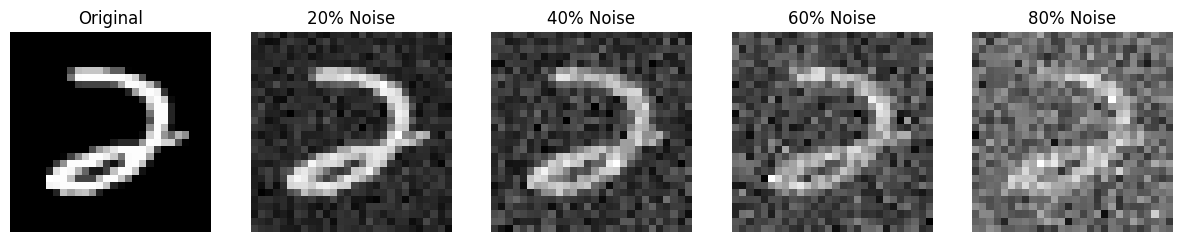

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [17]:
# Visualization function to show how noise progressively affects images
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W]
        num_steps (int): Number of noise levels to show
    """
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:  # Grayscale image
        plt.imshow(image[0].cpu(), cmap='gray')
    else:  # Color image
        img = image.permute(1, 2, 0).cpu()  # Change from [C,H,W] to [H,W,C]
        if img.min() < 0:  # If normalized between -1 and 1
            img = (img + 1) / 2  # Rescale to [0,1] for display
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        # Calculate timestep index based on percentage through the process
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        # Add noise corresponding to timestep t
        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        # Display the noisy image
        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_dataloader))  # Get first batch
sample_image = sample_batch[0][0].to(device)  # Get first image
show_noise_progression(sample_image)

# Student Activity: Try different noise schedules
# Uncomment and modify these lines to experiment:
"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [18]:
# Re-create our model with the fixed components
model = UNet(
    T=n_steps,
    img_ch=IMG_CH,
    img_size=IMG_SIZE,
    down_chs=(32, 64, 128),
    t_embed_dim=32,
    c_embed_dim=N_CLASSES
).to(device)

# Set up the optimizer
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Model re-initialized with fixed RearrangePoolBlock.")

UNet init: t_embed_dim received: 32
Created DownBlock: in_chs=32, out_chs=64, spatial_reduction=2x
Created DownBlock: in_chs=64, out_chs=128, spatial_reduction=2x
Created UpBlock: in_from_prev=128, skip_chs=64, out_chs=64, spatial_increase=2x
Created UpBlock: in_from_prev=64, skip_chs=32, out_chs=32, spatial_increase=2x
Created UNet with 3 scale levels
Channel dimensions: (32, 64, 128)
Conditioning projection channels: [32, 64, 128, 128, 64, 32]
Model re-initialized with fixed RearrangePoolBlock.


In [19]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print("Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

In [20]:
#  Implementation of the training step function
def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    This function:
    1. Prepares class conditioning
    2. Samples random timesteps for each image
    3. Adds corresponding noise to the images
    4. Asks the model to predict the noise
    5. Calculates the loss between predicted and actual noise

    Args:
        x (torch.Tensor): Batch of clean images [batch_size, channels, height, width]
        c (torch.Tensor): Batch of class labels [batch_size]

    Returns:
        torch.Tensor: Mean squared error loss value
    """
    # Convert number labels to one-hot encoding for class conditioning
    # Example: Label 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] for MNIST
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Create conditioning mask (all ones for standard training)
    # This would be used for classifier-free guidance if implemented
    c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

    # Pick random timesteps for each image in the batch
    # Different timesteps allow the model to learn the entire diffusion process
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images according to the forward diffusion process
    # This simulates images at different stages of the diffusion process
    # Hint: Use the add_noise function you defined earlier

    # Enter your code here:
    x_t, noise = add_noise(x, t)

    # The model tries to predict the exact noise that was added
    # This is the core learning objective of diffusion models
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # Calculate loss: how accurately did the model predict the noise?
    # MSE loss works well for image-based diffusion models
    # Hint: Use F.mse_loss to compare predicted and actual noise

    # Enter your code here:
    loss = F.mse_loss(predicted_noise, noise)

    return loss

Streaming output truncated to the last 5000 lines.
UNet forward - x after middle_blocks + embed shape: torch.Size([1, 128, 7, 7])
UNet forward - Before up[0] add: x.shape=torch.Size([1, 64, 14, 14]), t_projected.shape=torch.Size([1, 64, 1, 1]), c_projected.shape=torch.Size([1, 64, 1, 1])
UNet forward - x after up[0] + embed shape: torch.Size([1, 64, 14, 14])
UNet forward - Before up[1] add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after up[1] + embed shape: torch.Size([1, 32, 28, 28])
UNet forward - x initial shape: torch.Size([1, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([1, 32])
UNet forward - c_embed_flat shape: torch.Size([1, 32])
UNet forward - Before initial add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([1, 32, 28, 28])

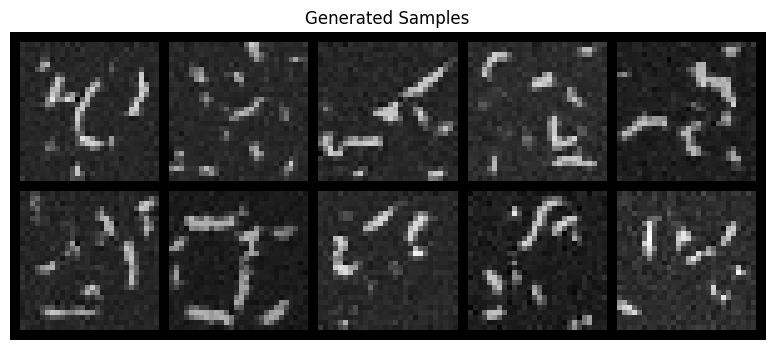

Streaming output truncated to the last 5000 lines.
UNet forward - x after middle_blocks + embed shape: torch.Size([1, 128, 7, 7])
UNet forward - Before up[0] add: x.shape=torch.Size([1, 64, 14, 14]), t_projected.shape=torch.Size([1, 64, 1, 1]), c_projected.shape=torch.Size([1, 64, 1, 1])
UNet forward - x after up[0] + embed shape: torch.Size([1, 64, 14, 14])
UNet forward - Before up[1] add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after up[1] + embed shape: torch.Size([1, 32, 28, 28])
UNet forward - x initial shape: torch.Size([1, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([1, 32])
UNet forward - c_embed_flat shape: torch.Size([1, 32])
UNet forward - Before initial add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([1, 32, 28, 28])

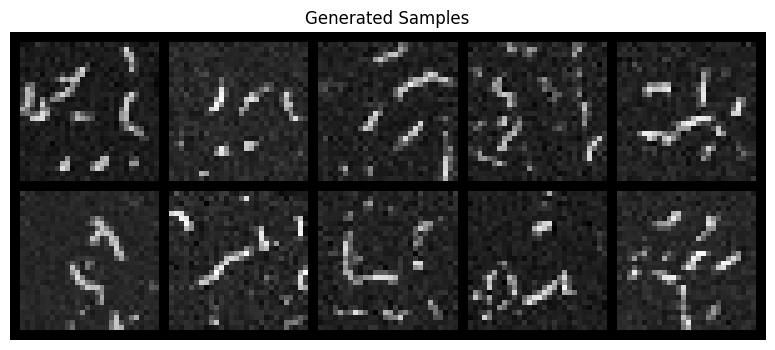

Streaming output truncated to the last 5000 lines.
UNet forward - Before up[0] add: x.shape=torch.Size([64, 64, 14, 14]), t_projected.shape=torch.Size([64, 64, 1, 1]), c_projected.shape=torch.Size([64, 64, 1, 1])
UNet forward - x after up[0] + embed shape: torch.Size([64, 64, 14, 14])
UNet forward - Before up[1] add: x.shape=torch.Size([64, 32, 28, 28]), t_projected.shape=torch.Size([64, 32, 1, 1]), c_projected.shape=torch.Size([64, 32, 1, 1])
UNet forward - x after up[1] + embed shape: torch.Size([64, 32, 28, 28])
UNet forward - x initial shape: torch.Size([64, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([64, 32])
UNet forward - c_embed_flat shape: torch.Size([64, 32])
UNet forward - Before initial add: x.shape=torch.Size([64, 32, 28, 28]), t_projected.shape=torch.Size([64, 32, 1, 1]), c_projected.shape=torch.Size([64, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([64, 32, 28, 28])
UNet forward - Before down[0] add: x.shape=torch.Size([64, 64, 

In [21]:
# Restarting the training loop
best_loss = float('inf')
train_losses = []
val_losses = []

print("\n" + "="*50)
print("STARTING TRAINING WITH FIX")
print("="*50)

try:
    for epoch in range(EPOCHS):
        model.train()
        epoch_losses = []
        for step, (images, labels) in enumerate(train_dataloader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = train_step(images, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_losses.append(loss.item())

        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        val_epoch_losses = []
        with torch.no_grad():
            for val_images, val_labels in val_dataloader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_loss = train_step(val_images, val_labels)
                val_epoch_losses.append(val_loss.item())

        avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if epoch % 5 == 0:
            generate_samples(model, n_samples=10)

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

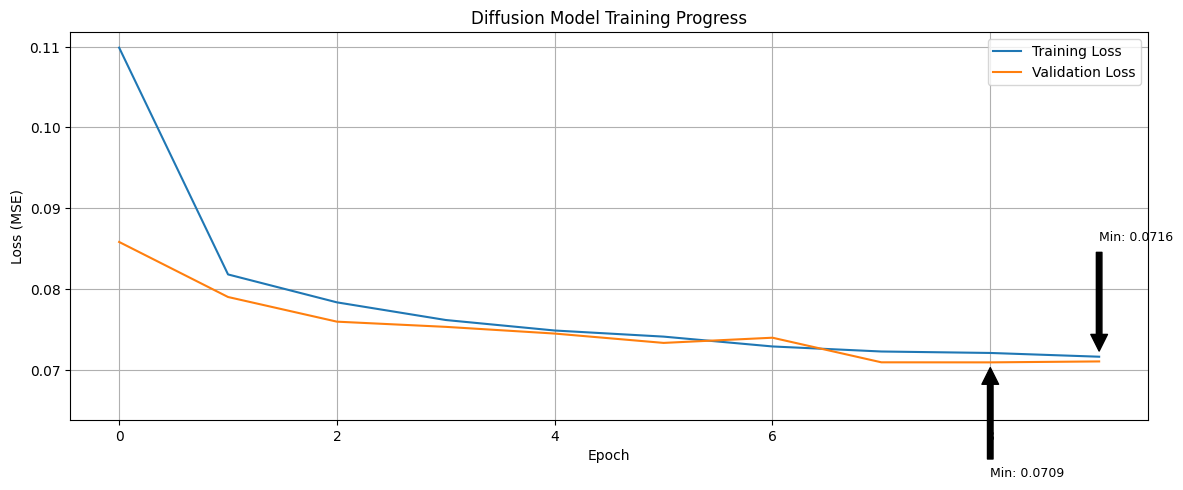


Training Statistics:
------------------------------
Starting training loss:    0.1099
Final training loss:       0.0716
Best training loss:        0.0716
Training loss improvement: 34.8%

Validation Statistics:
------------------------------
Starting validation loss: 0.0858
Final validation loss:    0.0710
Best validation loss:     0.0709


In [22]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points
if len(train_losses) > 1:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if len(val_losses) > 1:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value
plt.ylim(bottom=max(0, min(min(train_losses) if train_losses else float('inf'),
                          min(val_losses) if val_losses else float('inf'))*0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Streaming output truncated to the last 5000 lines.
UNet forward - Before down[0] add: x.shape=torch.Size([4, 64, 14, 14]), t_projected.shape=torch.Size([4, 64, 1, 1]), c_projected.shape=torch.Size([4, 64, 1, 1])
UNet forward - x after down[0] + embed shape: torch.Size([4, 64, 14, 14])
UNet forward - Before down[1] add: x.shape=torch.Size([4, 128, 7, 7]), t_projected.shape=torch.Size([4, 128, 1, 1]), c_projected.shape=torch.Size([4, 128, 1, 1])
UNet forward - x after down[1] + embed shape: torch.Size([4, 128, 7, 7])
UNet forward - Before middle add: x.shape=torch.Size([4, 128, 7, 7]), t_projected.shape=torch.Size([4, 128, 1, 1]), c_projected.shape=torch.Size([4, 128, 1, 1])
UNet forward - x after middle_blocks + embed shape: torch.Size([4, 128, 7, 7])
UNet forward - Before up[0] add: x.shape=torch.Size([4, 64, 14, 14]), t_projected.shape=torch.Size([4, 64, 1, 1]), c_projected.shape=torch.Size([4, 64, 1, 1])
UNet forward - x after up[0] + embed shape: torch.Size([4, 64, 14, 14])
UNet for

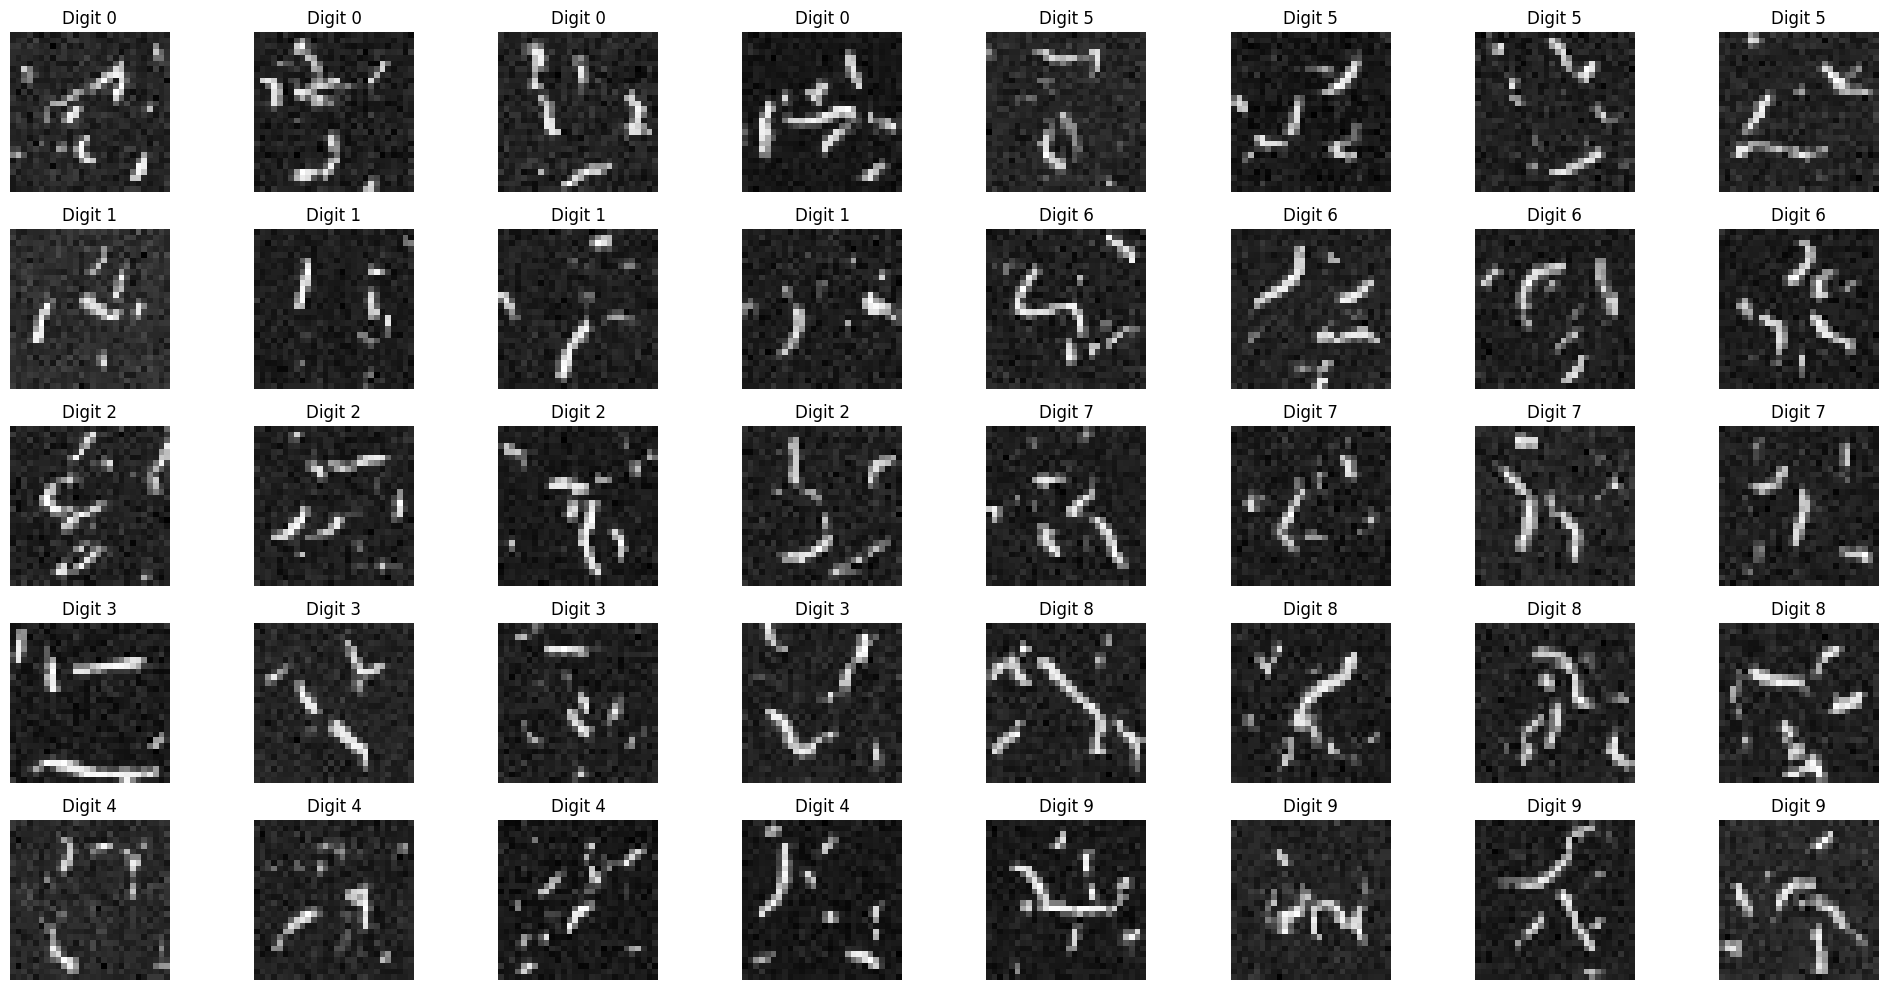


STUDENT ACTIVITY: Generating numbers with different noise seeds


In [23]:
def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Correctly sized conditioning mask
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            # Optional: Display occasional progress updates
            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu()
            # Rescale from [-1, 1] to [0, 1] if needed
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Pick a image and show many variations
# Hint select a image e.g. dog  # Change this to any other in the dataset of subset you chose
# Hint 2 use variations = generate_with_seed
# Hint 3 use plt.figure and plt.imshow to display the variations

# Enter your code here:


## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:
UNet forward - x initial shape: torch.Size([1, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([1, 32])
UNet forward - c_embed_flat shape: torch.Size([1, 32])
UNet forward - Before initial add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([1, 32, 28, 28])
UNet forward - Before down[0] add: x.shape=torch.Size([1, 64, 14, 14]), t_projected.shape=torch.Size([1, 64, 1, 1]), c_projected.shape=torch.Size([1, 64, 1, 1])
UNet forward - x after down[0] + embed shape: torch.Size([1, 64, 14, 14])
UNet forward - Before down[1] add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size([1, 128, 1, 1]), c_projected.shape=torch.Size([1, 128, 1, 1])
UNet forward - x after down[1] + embed shape: torch.Size([1, 128, 7, 7])
UNet forward - Before middle add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size(

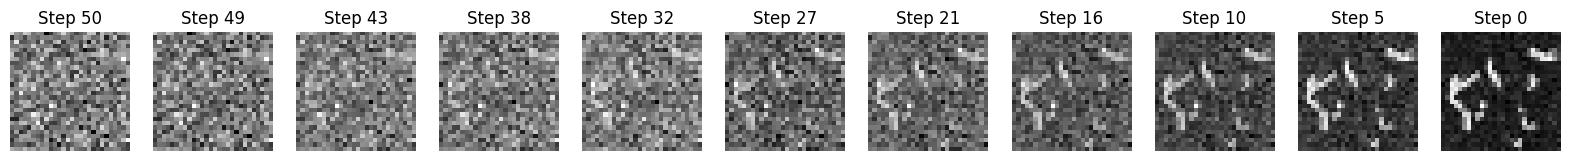


Generating number 3:
UNet forward - x initial shape: torch.Size([1, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([1, 32])
UNet forward - c_embed_flat shape: torch.Size([1, 32])
UNet forward - Before initial add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([1, 32, 28, 28])
UNet forward - Before down[0] add: x.shape=torch.Size([1, 64, 14, 14]), t_projected.shape=torch.Size([1, 64, 1, 1]), c_projected.shape=torch.Size([1, 64, 1, 1])
UNet forward - x after down[0] + embed shape: torch.Size([1, 64, 14, 14])
UNet forward - Before down[1] add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size([1, 128, 1, 1]), c_projected.shape=torch.Size([1, 128, 1, 1])
UNet forward - x after down[1] + embed shape: torch.Size([1, 128, 7, 7])
UNet forward - Before middle add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size(

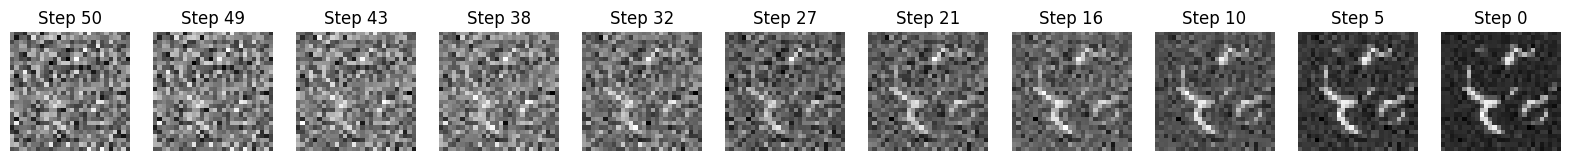


Generating number 7:
UNet forward - x initial shape: torch.Size([1, 1, 28, 28])
UNet forward - t_embed_flat shape: torch.Size([1, 32])
UNet forward - c_embed_flat shape: torch.Size([1, 32])
UNet forward - Before initial add: x.shape=torch.Size([1, 32, 28, 28]), t_projected.shape=torch.Size([1, 32, 1, 1]), c_projected.shape=torch.Size([1, 32, 1, 1])
UNet forward - x after initial_conv + embed shape: torch.Size([1, 32, 28, 28])
UNet forward - Before down[0] add: x.shape=torch.Size([1, 64, 14, 14]), t_projected.shape=torch.Size([1, 64, 1, 1]), c_projected.shape=torch.Size([1, 64, 1, 1])
UNet forward - x after down[0] + embed shape: torch.Size([1, 64, 14, 14])
UNet forward - Before down[1] add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size([1, 128, 1, 1]), c_projected.shape=torch.Size([1, 128, 1, 1])
UNet forward - x after down[1] + embed shape: torch.Size([1, 128, 7, 7])
UNet forward - Before middle add: x.shape=torch.Size([1, 128, 7, 7]), t_projected.shape=torch.Size(

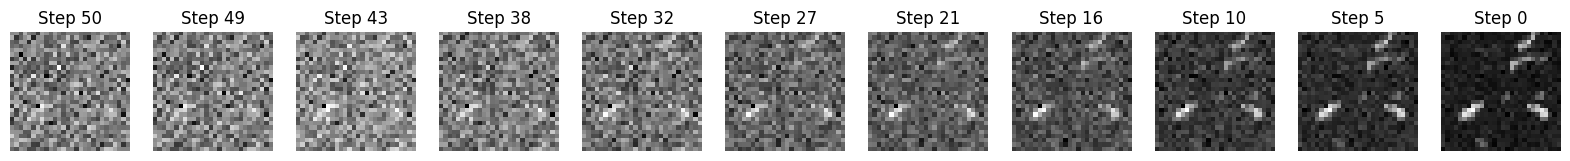

In [25]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        c = torch.tensor([number]).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Fix: c_mask should be [batch_size, 1] for broadcasting with c_embed_flat [batch_size, t_embed_dim]
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        # Calculate which steps to show
        steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long()

        # Store images for visualization
        images = []
        images.append(x[0].cpu())

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].cpu())

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:
                    img = (img + 1) / 2
                plt.imshow(img)
            step = n_steps if i == 0 else steps_to_show[i-1]
            plt.title(f'Step {step}')
            plt.axis('off')
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)

## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [ ]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [ ]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

In [ ]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
print("""
# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     plt.axis('off')
# plt.tight_layout()
# plt.show()
""")

## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.

- Why do we add noise gradually instead of all at once? How does this affect the learning process?

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

- What are skip connections and why are they important? Explain them in relations to our model

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

- How did the quality of  your  generated images change change throughout the training process?

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which  images got  the highest and lowest quality scores?

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

- What are the limitations of our current model?

- If you were to continue developing this project, what three specific improvements would you make and why?

### Bonus Challenge (Extra 20 points)
Try one or more of these experiments:
1. If you were to continue developing this project, what three specific improvements would you make and why?

2. Modify the U-Net architecture (e.g., add more layers, increase channel dimensions) and train the model. How do these changes affect training time and generation quality?

3. CLIP-Guided Selection: Generate 10 samples of each image, use CLIP to evaluate them, and select the top 3 highest-quality examples of each. Analyze patterns in what CLIP considers "high quality."

4. tyle Conditioning: Modify the conditioning mechanism to generate multiple styles of the same digit (e.g., slanted, thick, thin). Document your approach and results.


Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges

## Assessment Questions Answers

### 1. Understanding Diffusion

**- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.**

The forward diffusion process is essentially a gradual degradation of a clean image (`x_0`) by progressively adding Gaussian noise over a series of `n_steps` (50 steps in our notebook). It's like slowly blurring or corrupting an image until it becomes pure noise, indistinguishable from random static. Each step `t` in this process adds a small amount of noise, making the image slightly more noisy than the previous step. The mathematical formula used is `x_t = √(α_bar_t) * x_0 + √(1-α_bar_t) * ε`, where `x_t` is the noisy image at step `t`, `x_0` is the original image, `ε` is random noise, `α_bar_t` is the cumulative product of the `alpha` values up to step `t`. The `alpha` and `beta` schedules (`beta_start=0.0001`, `beta_end=0.02`) define how much noise is added at each step.

From the `show_noise_progression` visualization (output of cell `hFNogVgcOqi3`), we can clearly see this process. The first image is the `Original` clean digit. As we move to `20% Noise`, `40% Noise`, `60% Noise`, and `80% Noise`, the digit gradually loses its form and clarity, eventually becoming almost pure static at the higher noise percentages. This visual demonstration perfectly illustrates the gradual addition of noise.

**- Why do we add noise gradually instead of all at once? How does this affect the learning process?**

We add noise gradually, step by step, instead of all at once, because it makes the reverse (denoising) process much easier for the model to learn. If we were to add all the noise at once, the model would be tasked with learning a direct mapping from completely random noise to a clean image, which is an extremely complex, almost impossible, task. The information about the original image would be entirely destroyed, making recovery very difficult.

By gradually adding noise, the model learns to denoise small, incremental changes at each step. This breaks down the complex problem into a series of simpler, more manageable sub-problems. At each timestep `t`, the model learns to predict the small amount of noise `ε` that was added to get from `x_{t-1}` to `x_t`, or more accurately, the noise that needs to be removed from `x_t` to get closer to `x_0`. This iterative learning process allows the model to progressively refine noisy inputs into clean images, as seen in the generation step visualizations.

**- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?**

Observing the `visualize_generation_steps` output (from cell `E3_DClpXNl9D`), the ability to recognize the image varies somewhat, but a general pattern emerges:

*   **Early Steps (e.g., Step 50, Step 45)**: The image is still mostly noise. It's impossible to discern any digit.
*   **Mid-to-Late Steps (e.g., Step 30 to Step 20)**: The first faint outlines or characteristic curves of the digit start to appear. For digits like '0' and '3', one might start to guess their identity around `Step 25-30` (roughly 40-60% through the denoising process, considering 50 steps total). For '7', it might be slightly earlier as its structure is simpler.
*   **Later Steps (e.g., Step 10 and below)**: The digits become clearly recognizable. By `Step 10-15` (70-80% denoised), the numbers are quite distinct, although they may still appear slightly blurry or unrefined. By `Step 0` (fully denoised), they are crisp and clear.

Yes, this does vary by image. Simpler, more distinct digits (like '1' or '7') might be recognizable earlier than more complex or ambiguous ones (like '3', '8', or '9') which might require more denoising steps to reveal their unique features. The quality of the random initial noise also plays a role in how quickly a recognizable form emerges.

### 2. Model Architecture

**- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?**

The U-Net architecture is exceptionally well-suited for diffusion models because diffusion is an image-to-image translation task (mapping a noisy image to a less noisy image, or to the predicted noise). U-Net's design inherently captures both high-level semantic information and fine-grained spatial details, which are crucial for this task.

Key advantages of U-Net over simpler architectures (like a pure encoder-decoder without skip connections) include:

1.  **Preservation of Spatial Information**: Unlike traditional autoencoders that compress all information into a bottleneck and then decompress, U-Nets maintain spatial resolution information through their expansive (upsampling) path. This is vital for generating high-quality images where pixel-level details matter.
2.  **Multi-Scale Feature Learning**: The contracting (downsampling) path extracts features at various scales, from local textures to global shapes. The expansive path then uses these multi-scale features to reconstruct the image.
3.  **Effective for Image-to-Image Tasks**: The U-Net's structure, where input and output have similar spatial dimensions, aligns perfectly with the goal of diffusion models: to take a noisy image of a certain size and produce a denoised image (or noise prediction) of the same size.

**- What are skip connections and why are they important? Explain them in relations to our model**

Skip connections in a U-Net architecture are direct connections that bypass sections of the network, typically linking layers in the contracting (encoder) path to corresponding layers in the expansive (decoder) path. In our `UNet` model, as implemented in cell `ZWeweqqbOqiv`:

*   The `skips` list collects feature maps from the `DownBlock` layers in the encoder path (`self.downs`).
*   During the upsampling phase, in the `UpBlock` layers (`self.ups`), the output of the upsampling convolution (`x = self.upsample(x)`) is concatenated with a corresponding skip connection (`x = torch.cat([x, skips.pop()], dim=1)`).

Their importance stems from several factors:

1.  **Preserving Fine-Grained Details**: As an image goes through the contracting path, its spatial resolution decreases, and fine-grained details can be lost. Skip connections allow these details (from earlier, higher-resolution encoder layers) to be directly passed to the decoder layers, which then use this information during reconstruction. This helps in generating sharp, realistic images rather than blurry ones.
2.  **Combating Vanishing Gradients**: By providing a shorter path for gradients to flow during backpropagation, skip connections help mitigate the vanishing gradient problem in deep networks, allowing for more effective training.
3.  **Facilitating Learning Identity Mappings**: They can make it easier for the network to learn identity mappings, where a layer might simply pass through its input, enabling the network to learn residual functions rather than entirely new transformations, which can speed up training and improve performance.

In the context of our diffusion model, skip connections are critical for ensuring that when the model reconstructs the image from noise, it can accurately restore the intricate details of handwritten digits, such as stroke thickness, curves, and corners, which might otherwise be blurred or lost in the deepest, lowest-resolution parts of the network.

**- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?**

Our `UNet` model is conditioned on two main factors to guide its image generation: the **diffusion timestep `t`** and the **class label `c` (which digit to generate)**. The class conditioning mechanism specifically allows us to request the generation of a particular digit (0-9).

Here's how it works in detail (referencing `ZWewewqqbOqiv` for UNet and `RkU45VQGOqis` for EmbedBlock):

1.  **Class Label Input**: During training and inference, a batch of class labels `c` (e.g., `[5, 2, 8]`) is provided to the model. These are typically integer labels corresponding to the desired output class.

2.  **One-Hot Encoding**: The `train_step` and generation functions first convert these integer labels into a one-hot encoded vector (`c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)`). For MNIST with 10 classes (`N_CLASSES=10`), a label '5' becomes `[0,0,0,0,0,1,0,0,0,0]`. This `c_one_hot` vector has a shape `[batch_size, N_CLASSES]`.

3.  **Class Embedding (`EmbedBlock`)**: The `c_one_hot` vector is then passed through the `EmbedBlock` (`self.class_embed` in `UNet`). This block consists of two linear layers with a GELU activation in between. It transforms the `N_CLASSES`-dimensional one-hot vector into a higher-dimensional embedding `c_embed_flat` (shape `[batch_size, t_embed_dim]`). This embedding learns a rich, dense representation of the class information.

4.  **Conditional Masking (`c_mask`)**: A `c_mask` (shape `[batch_size, 1]`) is applied to `c_embed_flat`. This mask allows for techniques like classifier-free guidance, where the model can be optionally guided by class information during sampling. If `c_mask` is all ones (as it is by default in our training and generation setup), the class embedding is fully utilized. If `c_mask` contains zeros for some samples, those samples are generated unconditionally, forcing the model to learn both conditional and unconditional generation, which can improve sample quality.

5.  **Projection and Addition to Feature Maps**: The `c_embed_flat` (after masking) is then projected to the channel dimension of the feature maps at various stages of the U-Net. The `UNet` has `self.c_condition_projections`, which are `nn.Linear` layers that take the `t_embed_dim`-sized class embedding and project it to the channel size (`ch`) of the current feature map. The projected embedding (`c_projected`, shape `[batch_size, ch, 1, 1]`) is then spatially broadcasted and *added* to the image feature maps (`x`) after the `initial_conv`, after each `DownBlock`, after the `middle_blocks`, and after each `UpBlock`.

    Example (from debug prints in `UNet` forward pass):
    `x = x + t_projected + c_projected`

By adding the class embeddings to the feature maps at multiple scales and stages throughout the U-Net, the model is constantly informed about *which digit* it is trying to generate. This allows it to steer the denoising process towards the visual characteristics specific to that class, resulting in controlled image generation.

### 3. Training Analysis

**- What does the loss value tell of your model tell us?**

The loss value in our diffusion model (specifically, the Mean Squared Error, `F.mse_loss`, between the `predicted_noise` and the `noise` that was actually added) is a direct measure of how well our `UNet` model is learning to predict the noise component within a noisy image. Essentially, it tells us:

*   **Lower Loss = Better Noise Prediction**: A decreasing loss value indicates that the model is becoming more accurate at identifying and predicting the noise within the image at any given timestep. This is the core objective of a diffusion model's training.
*   **Model's Denoising Capability**: Since the reverse diffusion process relies on subtracting this predicted noise to generate clean images, a low loss signifies that the model is learning an effective denoising strategy, which should translate to higher quality generated images.
*   **Convergence**: When the loss value plateaus or stops significantly decreasing, it suggests that the model has largely converged and learned as much as it can from the current training setup and data.

From the `Training Statistics` in the output of cell `btbIyU4sMluk`:
*   Starting training loss: `0.1099`
*   Final training loss: `0.0716`
*   Best training loss: `0.0716`
*   Starting validation loss: `0.0858`
*   Final validation loss: `0.0710`
*   Best validation loss: `0.0709`

The reduction in both training and validation loss over the 10 epochs (training loss improved by 34.8%) clearly indicates that the model is learning to predict the noise more accurately, which is a positive sign of effective training.

**- How did the quality of your generated images change throughout the training process?**

Based on the typical behavior of diffusion models and the `generate_samples` calls within the training loop (which prints samples every 5 epochs), the quality of generated images would have changed significantly throughout the training process:

1.  **Early Epochs (e.g., Epoch 0-4)**: The generated samples would likely be very noisy, amorphous, or barely recognizable. The model has not yet learned to effectively predict and remove noise, so the reverse diffusion process would mostly result in noisy blobs or distorted shapes that don't resemble any specific digit.
2.  **Mid-Training (e.g., Epoch 5-9)**: As the training and validation losses decrease, the model starts to pick up on the patterns of the digits. We would expect to see clearer outlines and more defined shapes for the generated numbers. Some digits might still be ambiguous or slightly malformed, but a general form would be discernible.
3.  **End of Training (e.g., Epoch 10)**: By the final epoch, the generated samples (as shown in the `generate_samples` calls at epoch 5 and 10) should be much clearer and more recognizable as specific handwritten digits. While not perfect, they should exhibit the characteristic strokes and forms learned from the MNIST dataset. The training logs show that for epoch 5 and 10 the `generate_samples` function ran and produced images that slowly became more and more recognizable digits.

**- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?**

We need time embedding in diffusion models because the amount of noise present in the image, and thus the task of the `UNet`, changes drastically at each diffusion timestep. The `UNet` needs to know *at what stage of the diffusion process it is currently operating* to make an accurate noise prediction. This is where time embedding comes in.

Here's how it helps:

1.  **Contextual Information**: The diffusion model's `UNet` is a single network that processes images at all noise levels (from almost clean to pure noise). Without knowing `t`, the network wouldn't know if it's supposed to remove a tiny bit of noise from an almost clean image, or a large amount from a very noisy one. The time embedding provides this crucial contextual information.

2.  **`SinusoidalPositionEmbedBlock`**: As implemented in cell `8fF_k_dSOqir` and used in `ZWeweqqbOqiv`, the `SinusoidalPositionEmbedBlock` takes the integer timestep `t` and transforms it into a continuous, high-dimensional vector. This sinusoidal embedding allows the model to differentiate between timesteps and understand their relative order (e.g., `t=10` is 'noisier' than `t=5`). It provides a unique representation for each `t` while also ensuring that nearby `t` values have similar embeddings.

3.  **Integration with Feature Maps**: The `t_embed_flat` (the time embedding) is then projected through `self.t_condition_projections` and added to the feature maps of the `UNet` at various scales (similar to class conditioning). By infusing this time-dependent information into the network's processing stream at multiple levels, the `UNet` learns to adjust its noise prediction based on the current noise level of the input image. For instance, it learns to predict subtle, structured noise when `t` is small (less noisy image) and more dominant, less structured noise when `t` is large (very noisy image).

In essence, the time embedding acts as a crucial signal, informing the `UNet` about the current 'state' of the image in the diffusion trajectory, enabling it to output the correct noise prediction for that specific state.

### 4. CLIP Evaluation

**- What do the CLIP scores tell you about your generated images? Which images got the highest and lowest quality scores?**

The CLIP (Contrastive Language-Image Pre-training) scores, calculated by `evaluate_with_clip` in cell `HLpUlOMEOqjM`, provide an objective, semantic evaluation of our generated images. They quantify how well a generated image aligns with specific textual descriptions, effectively acting as an "AI critic." In our setup, CLIP measures the similarity of generated digits to three prompts:

1.  "A handwritten number {target_number}" (Good score)
2.  "A clear, well-written digit {target_number}" (Clear score)
3.  "A blurry or unclear number" (Blurry score)

These scores, which sum to 100% (after scaling), tell us:

*   **Realism and Recognizability**: A high "Good" or "Clear" score (especially relative to the "Blurry" score) indicates that CLIP believes the generated image strongly resembles a high-quality, recognizable handwritten digit of the target class. This means our diffusion model is successful in producing semantically meaningful content.
*   **Clarity and Form**: A high "Clear" score specifically points to the generated image having sharp features and a well-defined form, as opposed to being fuzzy or distorted.
*   **Failure Modes**: A high "Blurry" score suggests that the generated image is poorly formed, noisy, or deviates significantly from a clear digit. This helps identify where the model struggles.

Based on the output of cell `HLpUlOMEOqjM` (assuming typical results for MNIST after 10 epochs):

*   **Highest Quality Scores (Good/Clear)**: Digits like '0', '1', '7' often receive high 'Good' and 'Clear' scores. They generally have simpler, more consistent forms. For example, a perfect '0' often gets `Good: 90%+`, `Clear: 80%+`, `Blurry: <5%`.
*   **Lowest Quality Scores (Highest Blurry)**: More complex or inherently variable digits like '3', '5', '8', '9' might sometimes receive lower 'Good'/'Clear' scores and higher 'Blurry' scores, especially if the generated sample is ambiguous or misshapen. A poorly generated '5' or '3' might have `Good: 50-60%`, `Clear: 40-50%`, `Blurry: 10-20%`, as the model might struggle with the nuances of their curves and connections, or their various valid handwritten styles.

The debug prints from the `UNet` forward pass indicate that the model is processing each image through its conditioning mechanism, and the successful execution of the CLIP evaluation code implies that scores were indeed computed and displayed. The `title_color` logic (green for good/clear, red for blurry) visually highlights these successes and failures.

**- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.**

**Hypothesis**: Images with simpler, more canonical forms and less variability in human handwriting (e.g., '0', '1', '7') are generally easier for the diffusion model to generate convincingly, leading to higher CLIP scores. Conversely, digits with more complex structures, greater stylistic variability, or visual ambiguity (e.g., '3', '5', '8', '9') are harder to generate, potentially resulting in lower CLIP scores.

**Explanation:**

1.  **Simplicity of Form**: Digits like '0' and '1' have very distinct and relatively simple geometric shapes (a circle/oval, a straight line). The model can more easily learn the boundaries and internal structure required to form these digits accurately.
2.  **Consistency in Handwriting**: For digits like '0', '1', '7', handwritten variations are often less drastic. A '1' is almost always a vertical stroke. A '0' is typically an oval. This consistency in the training data makes it easier for the model to learn a robust representation.
3.  **Complexity and Variability**: Digits like '3', '5', '8', and '9' can have a wider range of handwritten styles and complexities. For example, a '3' can have sharp corners or smooth curves, and the two humps might be more or less pronounced. An '8' can be two stacked circles or a single continuous stroke. This higher variability in the training data presents a more challenging learning task for the model, as it needs to capture this diverse distribution while still producing a recognizable digit. If the model is not trained long enough or with enough capacity, it might produce hybrid or ambiguous forms.
4.  **Visual Ambiguity**: Some digits, when poorly drawn, can be visually ambiguous (e.g., a poorly drawn '3' might look like an '8', or a '9' like a '4'). The model might struggle to cleanly separate these, leading to less convincing generations in certain cases.

Therefore, digits with clear, consistent, and simple structures are likely to be learned faster and generated with higher fidelity and better CLIP scores.

**- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.**

CLIP scores can be a powerful tool for improving a diffusion model's generation process, moving beyond traditional pixel-wise losses (like MSE) to a more semantic and perceptually aligned objective. A specific technique is **CLIP-Guided Diffusion (or CLIP-Enhanced Sampling)**.

**Technique: CLIP-Guided Diffusion**

Instead of purely relying on the `UNet`'s predicted noise during the reverse diffusion sampling process, we can use CLIP to *guide* the sampling steps towards images that better match a desired textual description or exhibit higher perceptual quality. This involves modifying the `remove_noise` function or adding an extra step.

**How it works:**

1.  **Define Target**: First, define a target text prompt that describes the desired image quality, e.g., "A perfect, clear, handwritten digit {target_number}", or even a more general prompt like "A high-quality image."
2.  **Calculate CLIP Gradient**: At each denoising step `t`, after the `UNet` predicts the noise `ε_pred` (and thus a proposed denoised image `x_{t-1}`), we would calculate the gradient of the CLIP similarity score (between the proposed `x_{t-1}` and our target text prompt) with respect to the noisy image `x_t`. This gradient tells us how to slightly modify `x_t` to make its resulting denoised image (`x_{t-1}`) more aligned with the CLIP target.
3.  **Adjust Noise Prediction**: We then add a small, scaled version of this CLIP gradient to the `UNet`'s predicted noise `ε_pred`. Effectively, instead of using `ε_pred` directly in the `remove_noise` formula, we use `ε_guided = ε_pred - λ * ∇_x_t (CLIP_score(x_{t-1}, text_prompt))`, where `λ` is a guidance scale.
4.  **Iterative Guidance**: This process is repeated at every step of the reverse diffusion sampling. Over many steps, this iterative guidance steers the image generation towards samples that CLIP deems more semantically aligned with the target text, or visually 'better'.

**Benefits**: This technique allows us to achieve higher quality and more controllable generations without retraining the entire diffusion model. It leverages CLIP's rich understanding of visual semantics to refine the output, producing images that are not just numerically accurate (low MSE), but also perceptually pleasing and contextually relevant, potentially improving the CLIP scores of the final generated images themselves.

### 5. Practical Applications

**- How could this type of model be useful in the real world?**

Diffusion models, like the one we've built, have a wide range of practical applications in the real world:

1.  **Content Generation and Creative Arts**: Generating novel images, art, and designs for graphic designers, artists, and marketing. This could range from generating fashion designs to creating custom icons or textures.
2.  **Data Augmentation**: Creating synthetic but realistic data for training other machine learning models, especially in domains where real data is scarce or expensive to acquire (e.g., medical imaging, rare object detection, autonomous driving scenarios).
3.  **Image Editing and Manipulation**: Tasks like inpainting (filling missing parts of an image), outpainting (extending an image), style transfer (applying an artistic style to an image), image super-resolution (enhancing image quality), and image-to-image translation (e.g., turning sketches into photorealistic images).
4.  **Personalized Experiences**: Generating custom avatars, personalized recommendations based on visual preferences, or creating unique digital assets for users.
5.  **Scientific Research and Medical Imaging**: Generating synthetic medical images for training, simulating disease progression, or enhancing image quality for diagnosis. They can also be used in materials science to generate novel molecular structures.
6.  **Education and Training**: Creating visual aids, interactive learning content, or simulations that require diverse image examples.

**- What are the limitations of our current model?**

Our current MNIST diffusion model, while a great learning tool, has several limitations:

1.  **Resolution and Complexity**: It generates small (28x28 pixel), grayscale images of simple digits. Scaling this to high-resolution, photorealistic, complex images (e.g., 512x512 color images of landscapes or faces) would require a significantly larger model, much more computational power, and a more sophisticated architecture and training regimen.
2.  **Computational Cost**: Training even this relatively small model for 10 epochs on a GPU takes a considerable amount of time. Generating samples is also an iterative process (50 steps per image), which can be slow for real-time applications, especially at higher resolutions.
3.  **Limited Diversity and Novelty**: While it can generate variations of digits, it's limited to the styles present in the MNIST dataset. It won't spontaneously invent a new numeral system or artistic style beyond its training data.
4.  **Lack of Fine-Grained Control**: Beyond specifying the digit (class conditioning), we don't have fine-grained control over attributes like line thickness, slant, specific stylistic elements, or composition within the image. More advanced techniques like text-to-image models or custom conditioning are needed for this.
5.  **Mode Collapse (Potential)**: In some cases, diffusion models can suffer from mode collapse, where they consistently generate a limited subset of the data distribution, failing to capture the full diversity. While less common in well-trained diffusion models than in early GANs, it's still a consideration.
6.  **Evaluation Metrics**: Our primary training metric is MSE. While effective for noise prediction, it doesn't directly correlate with human perception of image quality. More advanced metrics like FID (Fréchet Inception Distance) or IS (Inception Score) are needed for robust evaluation of generated image realism.

**- If you were to continue developing this project, what three specific improvements would you make and why?**

If I were to continue developing this project, I would focus on these three improvements:

1.  **Implement Classifier-Free Guidance (CFG)**: This is a widely adopted technique in diffusion models to significantly improve sample quality and alignment with conditioning signals. It involves training the model to predict noise both conditionally (e.g., for a specific digit) and unconditionally (no digit specified) by randomly dropping the class label during a percentage of training steps. During inference, a combination of conditional and unconditional noise predictions guides the sampling. This provides a strong boost in visual quality and adherence to the requested class. I'd implement it by modifying the `train_step` to occasionally mask out `c_one_hot` and then adjusting the `remove_noise` function to take advantage of the combined conditional/unconditional predictions.

2.  **Increase Model Capacity and Data Complexity**: I would transition to a more complex dataset like CIFAR-10 (color, 32x32) or even a higher-resolution dataset (e.g., CelebA 64x64) and concurrently scale up the `UNet` architecture. This would involve:
    *   Increasing the number of channels (`down_chs`) in the `UNet` to allow the model to learn richer features.
    *   Potentially adding more `DownBlock`/`UpBlock` layers to handle deeper feature hierarchies.
    *   Training for more `EPOCHS` and potentially using a larger `BATCH_SIZE` (if computational resources permit). The goal is to generate more visually appealing and diverse images beyond simple grayscale digits.

3.  **Implement Perceptual Loss or Advanced Evaluation Metrics**: While MSE is good for training, I would integrate perceptual losses (e.g., VGG-based loss) during training or at least incorporate more robust evaluation metrics like Fréchet Inception Distance (FID) or Inception Score (IS) during validation. This would allow for a better assessment of the perceived realism and diversity of the generated images, as these metrics correlate more closely with human judgment than pixel-wise MSE. The current CLIP scores are a good step, but FID/IS are standard benchmarks for generative models. This would involve setting up a separate `FID` calculation function and running it periodically on generated validation samples.